# Resumen comparativo — las siete corridas, en una sola lectura

Este notebook no introduce ningún experimento nuevo: junta **todo lo que se
midió** en las fases 7, 8 y 9 y lo pone en una sola tabla y un puñado de
gráficos, para responder de una vez las cuatro preguntas que el proyecto se fue
haciendo.

| # | La pregunta | Dónde se midió | Corridas que la contestan |
|---|---|---|---|
| 1 | ¿Conviene más **dimensión**? | Fase 7 | `5k_50_2` vs `5k_100_2` |
| 2 | ¿Conviene más **contexto**? | Fases 7 y 9 | 4 corridas, en las dos arquitecturas |
| 3 | ¿Conviene **skip-gram** sobre CBOW? | Fases 8 y 9 | 4 corridas, en los dos contextos |
| 4 | ¿Conviene entrenar con **`<UNK>`**? | Fase 7 | `5k_50_2` vs `ablacion_unk` |

Las siete corridas comparten el mismo vocabulario de 5.000 palabras (construido
sobre el corpus completo y prestado con `vocab_from`), las mismas 2M de oraciones
de `muestra_2m.txt`, 15 épocas, batch 512, lr 0,003, 10 negativos y semilla 42.
Cada corrida mueve **una** cosa respecto de la línea de base `piloto_5k_50_2`,
salvo `piloto_5k_100_5` y `piloto_sg_5k_50_5`, que son las esquinas de sus
respectivos 2×2.

## Las dos reglas que ordenan todo lo que sigue

1. **La loss casi nunca se compara.** Solo tiene sentido entre corridas que
   resuelven la misma tarea: misma arquitectura, mismo contexto y mismo
   tratamiento de los OOV. De las siete corridas, únicamente `5k_50_2` y
   `5k_100_2` —y el par `5k_50_5` / `5k_100_5`— caen en el mismo grupo. Para todo
   lo demás, comparar loss es comparar cosas distintas.

2. **La métrica que sí cruza todo es la precisión en analogías**, y la forma
   correcta de comparar dos corridas es **pareada** (`mcnemar` + `paired_difference`),
   porque las siete responden exactamente los mismos 286 ítems.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np

from src.compare import collect, mcnemar, paired_difference
from src.config import load_config
from src.evaluate import load_embeddings, nearest_neighbors

plt.rcParams["figure.dpi"] = 110

CORRIDAS = [
    "piloto_5k_50_2",        # línea de base
    "piloto_5k_100_2",       # +dimensión
    "piloto_5k_50_5",        # +contexto
    "piloto_5k_100_5",       # +dimensión +contexto
    "ablacion_unk_5k_50_2",  # con <UNK>
    "piloto_sg_5k_50_2",     # skip-gram
    "piloto_sg_5k_50_5",     # skip-gram +contexto
]
FILAS = {f["name"]: f for f in collect(CORRIDAS)}
CATEGORIAS = list(FILAS[CORRIDAS[0]]["categories"])

ETIQUETA = {
    "piloto_5k_50_2":        "CBOW 50·2  (base)",
    "piloto_5k_100_2":       "CBOW 100·2",
    "piloto_5k_50_5":        "CBOW 50·5",
    "piloto_5k_100_5":       "CBOW 100·5",
    "ablacion_unk_5k_50_2":  "CBOW 50·2 + <UNK>",
    "piloto_sg_5k_50_2":     "skip-gram 50·2",
    "piloto_sg_5k_50_5":     "skip-gram 50·5",
}
COLOR = {n: ("#b5361f" if FILAS[n]["arch"] == "skipgram" else "#2a6f97")
         for n in CORRIDAS}
COLOR["piloto_5k_50_2"] = "#7f8c9b"
COLOR["ablacion_unk_5k_50_2"] = "#b5651d"


def aciertos(nombre, categoria=None):
    return [h for cat, *_, h in FILAS[nombre]["items"]
            if categoria is None or cat == categoria]


print(f"{'corrida':<20} {'arq':<9} {'dim':>4} {'ctx':>4} {'<UNK>':>6} "
      f"{'pares/época':>13} {'min/ép':>7} {'analogías':>10} {'IC 95%':>16}")
print("-" * 100)
for nombre in CORRIDAS:
    f = FILAS[nombre]
    lo, hi = f["accuracy_ci"]
    print(f"{ETIQUETA[nombre]:<20} {f['arch']:<9} {f['embedding_dim']:>4} "
          f"{f['context_size']:>4} {'sí' if not f['drop_unknown'] else 'no':>6} "
          f"{f['pairs_per_epoch']:>13,} "
          f"{f['seconds_per_epoch_median']/60:>7.1f} "
          f"{f['accuracy']:>10.1%} {f'[{lo:.1%}, {hi:.1%}]':>16}")

corrida              arq        dim  ctx  <UNK>   pares/época  min/ép  analogías           IC 95%
----------------------------------------------------------------------------------------------------
CBOW 50·2  (base)    cbow        50    2     no     5,009,035     2.6      41.3%   [35.7%, 47.0%]
CBOW 100·2           cbow       100    2     no     5,009,035     2.6      54.2%   [48.4%, 59.9%]
CBOW 50·5            cbow        50    5     no     5,009,035     2.7      42.3%   [36.7%, 48.1%]
CBOW 100·5           cbow       100    5     no     5,009,035     2.7      49.7%   [43.9%, 55.4%]
CBOW 50·2 + <UNK>    cbow        50    2     sí     5,067,178     2.6      44.4%   [38.8%, 50.2%]
skip-gram 50·2       skipgram    50    2     no    13,865,356     5.4      40.2%   [34.7%, 46.0%]
skip-gram 50·5       skipgram    50    5     no    24,968,216     7.0      36.7%   [31.3%, 42.4%]


---

## 1. El panorama: las siete, ordenadas

Ordenadas por precisión, con su intervalo de Wilson. La franja gris marca el
intervalo de la línea de base: **todo lo que cae dentro de esa franja es
indistinguible de no haber hecho nada**.

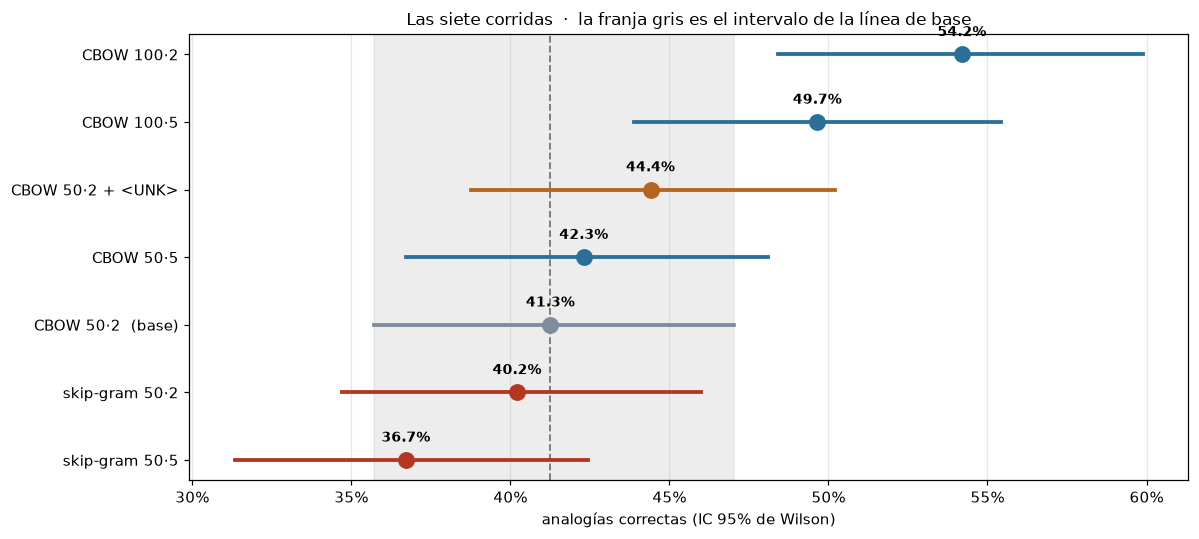

Corridas cuyo intervalo se superpone con el de la base (5 de 6):
  · skip-gram 50·5
  · skip-gram 50·2
  · CBOW 50·5
  · CBOW 50·2 + <UNK>
  · CBOW 100·5


In [2]:
orden = sorted(CORRIDAS, key=lambda n: FILAS[n]["accuracy"])

fig, ax = plt.subplots(figsize=(11, 5))

base_lo, base_hi = FILAS["piloto_5k_50_2"]["accuracy_ci"]
ax.axvspan(base_lo, base_hi, color="#bbb", alpha=0.25, zorder=0)
ax.axvline(FILAS["piloto_5k_50_2"]["accuracy"], color="#777",
           linestyle="--", linewidth=1.2, zorder=1)

for i, nombre in enumerate(orden):
    f = FILAS[nombre]
    lo, hi = f["accuracy_ci"]
    ax.plot([lo, hi], [i, i], color=COLOR[nombre], linewidth=2.5, zorder=2)
    ax.plot(f["accuracy"], i, "o", color=COLOR[nombre], markersize=10, zorder=3)
    ax.annotate(f"{f['accuracy']:.1%}", (f["accuracy"], i),
                textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=9, fontweight="bold")

ax.set_yticks(range(len(orden)))
ax.set_yticklabels([ETIQUETA[n] for n in orden])
ax.set_xlabel("analogías correctas (IC 95% de Wilson)")
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Las siete corridas  ·  la franja gris es el intervalo de la línea de base",
             fontsize=11)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

dentro = [ETIQUETA[n] for n in orden
          if FILAS[n]["accuracy_ci"][0] < base_hi and FILAS[n]["accuracy_ci"][1] > base_lo
          and n != "piloto_5k_50_2"]
print(f"Corridas cuyo intervalo se superpone con el de la base ({len(dentro)} de 6):")
for d in dentro:
    print(f"  · {d}")

Los intervalos de Wilson son una primera lectura, pero son **conservadores** acá:
tratan a cada corrida como una muestra independiente cuando en realidad las siete
responden los mismos 286 ítems. La comparación pareada es más sensible, y es la
que sigue.

---

## 2. Las cuatro preguntas, con su tamaño de efecto

Un *forest plot*: cada línea es una comparación pareada contra su propia
referencia. El punto es la diferencia de precisión, la barra su intervalo del 95%
calculado **sobre los pares**, y la línea vertical en cero es "no hay efecto".
Una barra que cruza el cero es un efecto que no se puede distinguir del azar.

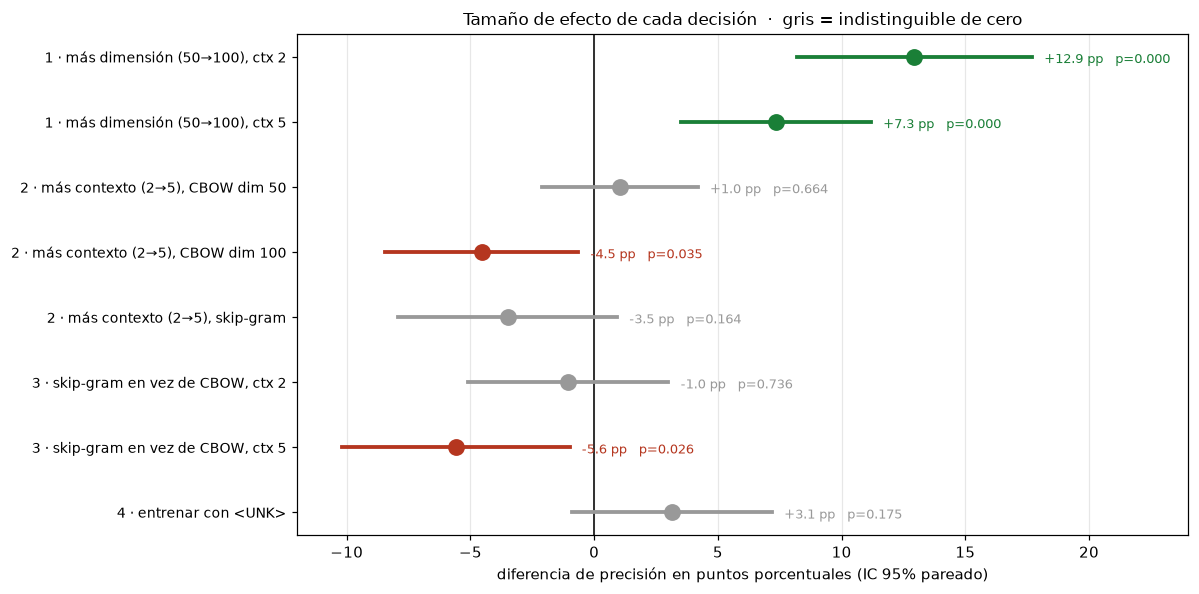

In [3]:
EFECTOS = [
    ("1 · más dimensión (50→100), ctx 2",  "piloto_5k_50_2",    "piloto_5k_100_2"),
    ("1 · más dimensión (50→100), ctx 5",  "piloto_5k_50_5",    "piloto_5k_100_5"),
    ("2 · más contexto (2→5), CBOW dim 50",   "piloto_5k_50_2",    "piloto_5k_50_5"),
    ("2 · más contexto (2→5), CBOW dim 100",  "piloto_5k_100_2",   "piloto_5k_100_5"),
    ("2 · más contexto (2→5), skip-gram",     "piloto_sg_5k_50_2", "piloto_sg_5k_50_5"),
    ("3 · skip-gram en vez de CBOW, ctx 2",   "piloto_5k_50_2",    "piloto_sg_5k_50_2"),
    ("3 · skip-gram en vez de CBOW, ctx 5",   "piloto_5k_50_5",    "piloto_sg_5k_50_5"),
    ("4 · entrenar con <UNK>",                "piloto_5k_50_2",    "ablacion_unk_5k_50_2"),
]

resultados = []
for etiqueta, a, b in EFECTOS:
    d = paired_difference(aciertos(a), aciertos(b))
    resultados.append((etiqueta, d))

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axvline(0, color="#333", linewidth=1.3, zorder=1)

for i, (etiqueta, d) in enumerate(reversed(resultados)):
    significativo = d["p_value"] < 0.05
    color = ("#1a7f37" if d["delta"] > 0 else "#b5361f") if significativo else "#999"
    lo, hi = d["ci"]
    ax.plot([lo * 100, hi * 100], [i, i], color=color, linewidth=2.5, zorder=2)
    ax.plot(d["delta"] * 100, i, "o", color=color, markersize=10, zorder=3)
    ax.annotate(f"{d['delta']*100:+.1f} pp   p={d['p_value']:.3f}",
                (hi * 100, i), textcoords="offset points", xytext=(8, -4),
                fontsize=8.5, color=color)

ax.set_yticks(range(len(resultados)))
ax.set_yticklabels([e for e, _ in reversed(resultados)], fontsize=9)
ax.set_xlabel("diferencia de precisión en puntos porcentuales (IC 95% pareado)")
ax.set_xlim(-12, 24)
ax.set_title("Tamaño de efecto de cada decisión  ·  gris = indistinguible de cero",
             fontsize=11)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [4]:
print(f"{'efecto':<40} {'delta':>8} {'IC 95%':>20} {'p':>8}")
print("-" * 80)
for etiqueta, d in resultados:
    lo, hi = d["ci"]
    marca = " *" if d["p_value"] < 0.05 else ""
    print(f"{etiqueta:<40} {d['delta']*100:>+7.1f} pp "
          f"{f'[{lo*100:+.1f}, {hi*100:+.1f}]':>20} {d['p_value']:>8.4f}{marca}")

print()
gana = [e for e, d in resultados if d["p_value"] < 0.05 and d["delta"] > 0]
pierde = [e for e, d in resultados if d["p_value"] < 0.05 and d["delta"] < 0]
nada = [e for e, d in resultados if d["p_value"] >= 0.05]
print(f"efectos positivos y significativos : {len(gana)}")
for e in gana:
    print(f"   + {e}")
print(f"efectos negativos y significativos : {len(pierde)}")
for e in pierde:
    print(f"   - {e}")
print(f"indistinguibles de cero            : {len(nada)}")
for e in nada:
    print(f"   = {e}")

efecto                                      delta               IC 95%        p
--------------------------------------------------------------------------------
1 · más dimensión (50→100), ctx 2          +12.9 pp        [+8.2, +17.7]   0.0000 *
1 · más dimensión (50→100), ctx 5           +7.3 pp        [+3.5, +11.2]   0.0003 *
2 · más contexto (2→5), CBOW dim 50         +1.0 pp         [-2.1, +4.2]   0.6636
2 · más contexto (2→5), CBOW dim 100        -4.5 pp         [-8.4, -0.6]   0.0351 *
2 · más contexto (2→5), skip-gram           -3.5 pp         [-7.9, +0.9]   0.1641
3 · skip-gram en vez de CBOW, ctx 2         -1.0 pp         [-5.1, +3.0]   0.7359
3 · skip-gram en vez de CBOW, ctx 5         -5.6 pp        [-10.2, -1.0]   0.0259 *
4 · entrenar con <UNK>                      +3.1 pp         [-0.9, +7.2]   0.1755

efectos positivos y significativos : 2
   + 1 · más dimensión (50→100), ctx 2
   + 1 · más dimensión (50→100), ctx 5
efectos negativos y significativos : 2
   - 2 · más conte

---

## 3. Costo contra calidad

Un experimento solo vale si su costo es asumible. Acá, cada corrida ubicada por
lo que **cuesta** (minutos por época, mediana) y lo que **rinde** (precisión).
Arriba a la izquierda es el cuadrante bueno: mucho rinde, poco cuesta.

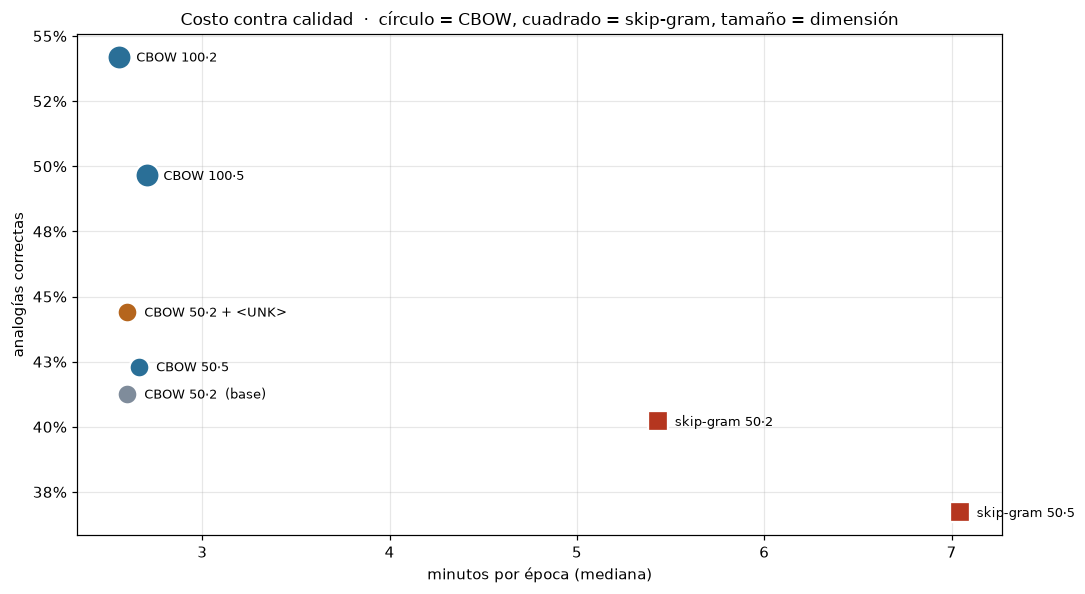

mejor precisión : CBOW 100·2  (54.2%, 2.6 min/época)
más barata      : CBOW 100·2  (54.2%, 2.6 min/época)


In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for nombre in CORRIDAS:
    f = FILAS[nombre]
    x = f["seconds_per_epoch_median"] / 60
    y = f["accuracy"]
    marca = "s" if f["arch"] == "skipgram" else "o"
    tamanio = 90 + f["embedding_dim"] * 1.6
    ax.scatter(x, y, s=tamanio, marker=marca, color=COLOR[nombre],
               edgecolor="white", linewidth=1.5, zorder=3)
    ax.annotate(ETIQUETA[nombre], (x, y), textcoords="offset points",
                xytext=(11, -3), fontsize=8.5)

ax.set_xlabel("minutos por época (mediana)")
ax.set_ylabel("analogías correctas")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Costo contra calidad  ·  círculo = CBOW, cuadrado = skip-gram, "
             "tamaño = dimensión", fontsize=11)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

mejor = max(CORRIDAS, key=lambda n: FILAS[n]["accuracy"])
barata = min(CORRIDAS, key=lambda n: FILAS[n]["seconds_per_epoch_median"])
print(f"mejor precisión : {ETIQUETA[mejor]}  "
      f"({FILAS[mejor]['accuracy']:.1%}, {FILAS[mejor]['seconds_per_epoch_median']/60:.1f} min/época)")
print(f"más barata      : {ETIQUETA[barata]}  "
      f"({FILAS[barata]['accuracy']:.1%}, {FILAS[barata]['seconds_per_epoch_median']/60:.1f} min/época)")

---

## 4. El perfil por categoría

Las cinco categorías del set de analogías no miden lo mismo. `país → gentilicio`
es una relación **temática** (los dos términos aparecen en los mismos textos);
`plural` y `verbo: presente → pasado` son **inflexionales** (misma palabra, otra
forma). Separarlas es lo que dejó ver, en la Fase 7, que subir la dimensión
arreglaba justo lo que estaba roto.

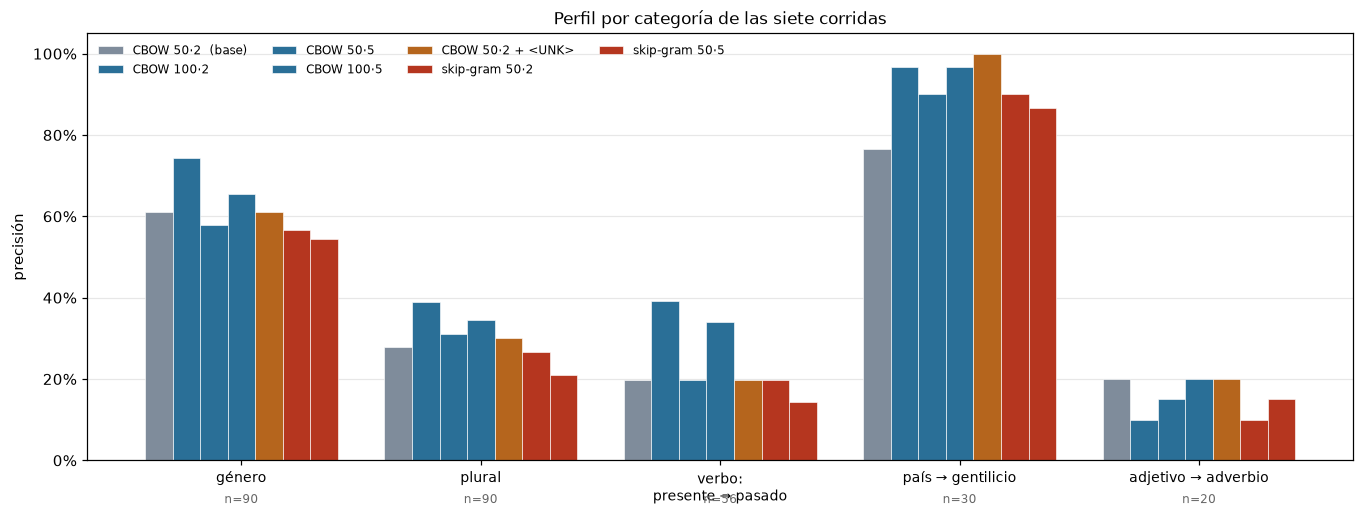

rango de precisión por categoría entre las siete corridas:
  género                      54.4% ..  74.4%   (amplitud 20.0 pp, n=90)
  plural                      21.1% ..  38.9%   (amplitud 17.8 pp, n=90)
  verbo: presente → pasado    14.3% ..  39.3%   (amplitud 25.0 pp, n=56)
  país → gentilicio           76.7% .. 100.0%   (amplitud 23.3 pp, n=30)
  adjetivo → adverbio         10.0% ..  20.0%   (amplitud 10.0 pp, n=20)


In [6]:
fig, ax = plt.subplots(figsize=(12.5, 4.8))

x = np.arange(len(CATEGORIAS))
ancho = 0.115
for i, nombre in enumerate(CORRIDAS):
    valores = [FILAS[nombre]["categories"][c]["accuracy"] for c in CATEGORIAS]
    ax.bar(x + (i - 3) * ancho, valores, ancho,
           label=ETIQUETA[nombre], color=COLOR[nombre],
           edgecolor="white", linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels([c.replace(": ", ":\n") for c in CATEGORIAS], fontsize=9)
ax.set_ylabel("precisión")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Perfil por categoría de las siete corridas", fontsize=11)
ax.legend(frameon=False, ncol=4, fontsize=8)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
for xi, cat in zip(x, CATEGORIAS):
    ax.text(xi, -0.10, f"n={FILAS[CORRIDAS[0]]['categories'][cat]['evaluated']}",
            ha="center", fontsize=8, color="#666", transform=ax.get_xaxis_transform())
plt.tight_layout()
plt.show()

print("rango de precisión por categoría entre las siete corridas:")
for cat in CATEGORIAS:
    vals = [FILAS[n]["categories"][cat]["accuracy"] for n in CORRIDAS]
    n_items = FILAS[CORRIDAS[0]]["categories"][cat]["evaluated"]
    print(f"  {cat:<26} {min(vals):6.1%} .. {max(vals):6.1%}   "
          f"(amplitud {(max(vals)-min(vals))*100:4.1f} pp, n={n_items})")

---

## 5. Vecinos cercanos: lo que se ve al usarlos

La precisión en analogías separa configuraciones que "a ojo" se parecen mucho.
Vale la pena ver cuánto se parecen.

In [7]:
MUESTRA = ["piloto_5k_50_2", "piloto_5k_100_2", "piloto_sg_5k_50_5"]
CARGADOS = [(n, *load_embeddings(load_config(f"configs/{n}.yaml"))) for n in MUESTRA]

for palabra in ["febrero", "tres", "mujer", "argentina", "dijo"]:
    print(f"\n{palabra}")
    for nombre, emb, voc in CARGADOS:
        vecinos = nearest_neighbors(palabra, emb, voc, k=6)
        print(f"  {ETIQUETA[nombre]:<20} " + ", ".join(w for w, _ in vecinos))


febrero
  CBOW 50·2  (base)    marzo, abril, octubre, mayo, julio, junio
  CBOW 100·2           marzo, abril, mayo, octubre, junio, julio
  skip-gram 50·5       octubre, abril, mayo, junio, marzo, julio

tres
  CBOW 50·2  (base)    cuatro, dos, cinco, siete, ocho, seis
  CBOW 100·2           cuatro, dos, cinco, seis, siete, ocho
  skip-gram 50·5       cuatro, ocho, cinco, seis, siete, dos

mujer
  CBOW 50·2  (base)    niña, infancia, niño, hermosa, vida, amiga
  CBOW 100·2           niña, niño, mujeres, infancia, hermosa, familia
  skip-gram 50·5       niña, niño, vida, mujeres, infancia, niñas

argentina
  CBOW 50·2  (base)    argentino, republica, chile, paraguay, mendoza, uruguay
  CBOW 100·2           republica, argentino, paraguay, chile, uruguay, brasil
  skip-gram 50·5       republica, argentino, aires, buenos, afines, uruguay

dijo
  CBOW 50·2  (base)    decía, sabía, dijeron, dije, llamó, dijiste
  CBOW 100·2           sabía, dije, decía, pensaba, dijeron, creía
  skip-gram 5

---
# 6. Conclusiones

## Las cuatro preguntas, contestadas

**1 · ¿Conviene más dimensión? Sí — es la única decisión que rindió.**
**+12,9 pp** con contexto 2 (IC [+8,2, +17,7], p < 0,0001) y +7,3 pp con contexto
5. Es el único efecto grande del proyecto, mejora justo lo que estaba roto —la
morfología: `verbo` 19,6% → 39,3%, `plural` 27,8% → 38,9%— y **no cuesta tiempo**:
2,6 min/época, igual que la línea de base, porque el cuello de botella es la CPU
generando pares y no la GPU multiplicando matrices. Solo cuesta disco: 5,7 → 11,4 MB.

**2 · ¿Conviene más contexto? No, en ninguna de las dos arquitecturas.**
Tres corridas lo probaron y ninguna ganó: CBOW dim 50 +1,0 pp (p = 0,66), CBOW
dim 100 **−4,5 pp** (p = 0,035), skip-gram −3,5 pp (p = 0,16). Lo único que
mejora con ventana ancha es `país → gentilicio`, la única relación temática del
set, y solo mientras le queda margen.

**3 · ¿Conviene skip-gram? No a esta escala.**
Empate con contexto 2 (−1,0 pp, p = 0,74) y derrota con contexto 5 (**−5,6 pp**,
p = 0,026), pagando entre 2,1× y 2,6× el tiempo. Con la salvedad de siempre: un
vocabulario de 5.000 sobre 2.028M de tokens **no tiene palabras raras** —la
última, `cercana`, aparece 33.838 veces— y ahí es donde skip-gram suele ganar. El
resultado vale para esta escala, no para skip-gram en general.

**4 · ¿Conviene entrenar con `<UNK>`? Da igual.**
+3,1 pp con IC [−0,9, +7,2] y p = 0,18: indistinguible de cero. El subsampling ya
elimina el 99,3% de los `<UNK>`, así que la bandera decide el destino del 0,7%
que queda. Se mantiene `drop_unknown: true` por **costo e higiene**, no por
calidad.

## El patrón: de ocho decisiones, una sola rindió

Tres de las ocho comparaciones son significativas: una a favor (la dimensión, en
los dos contextos) y dos en contra (ensanchar con dim 100, y skip-gram con
contexto 5). Las otras cinco no se distinguen de cero.

> **Corrección por comparaciones múltiples.** Ocho pruebas sobre el mismo set de
> ítems inflan la probabilidad de encontrar algo por azar. Con Bonferroni el
> umbral baja a 0,00625: **los dos efectos de dimensión lo pasan holgadamente**
> (p < 0,0001 y p = 0,0003); los dos efectos negativos (p = 0,035 y p = 0,026)
> **no**. O sea: la conclusión sobre la dimensión es sólida, y las dos
> conclusiones en contra son señales consistentes pero no cerradas.

## Un recordatorio que aparece dos veces en los datos

**Menor loss no es mejor modelo.** `piloto_5k_100_5` tiene la loss más baja de las
corridas CBOW (2,5905) y no es la mejor en analogías (49,7% contra 54,2%).
Eligiendo por la curva de entrenamiento habríamos elegido mal. La loss es lo que
se optimiza; la calidad del espacio vectorial es lo que importa, y no son lo
mismo.

Relacionado: de las siete corridas, la loss solo es comparable dentro de tres
grupos chicos. Entre arquitecturas ni siquiera es la misma tarea.

## Tres hipótesis propias que el proyecto refutó

Las tres estaban escritas **antes** de medir, y las tres se cayeron:

1. *"La debilidad morfológica viene de `context_size=2`; subirlo la va a
   arreglar"* (Fase 6). Falso en los dos sentidos: subir el contexto **empeoró**
   la morfología, y la causa real era la dimensión.
2. *"Dejar `<UNK>` hace que el modelo gaste capacidad prediciendo un comodín"*
   (Fase 6). A 0,97% del stream esa capacidad es despreciable.
3. *"Skip-gram aprovecha la ventana ancha mejor que CBOW porque no promedia"*
   (Fase 9). Al revés: si el vecino lejano es ruido para la tarea, promediarlo es
   una **defensa**. Skip-gram, que le da peso completo a cada vecino, se degradó
   más.

Es el argumento más fuerte que dejó el proyecto a favor de montar la grilla en
vez de razonar de memoria.

## La configuración recomendada

**`piloto_5k_100_2`** — CBOW, dim 100, contexto 2. 54,2% en analogías, 2,6
min/época, 11,4 MB de checkpoint. Ninguna de las tres corridas posteriores la
superó.

